In [ ]:

# Healthcare Analytics Project
# Module : Exploratory Data Analysis (EDA)
# =====================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

plt.style.use("ggplot")

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [2]:
df = pd.read_csv("../Data/cleaned/healthcare_cleaned.csv")

In [3]:
df["Date of Admission"] = pd.to_datetime(df["Date of Admission"])

df["Discharge Date"] = pd.to_datetime(df["Discharge Date"])

In [4]:
print(f"Rows : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

Rows : 54966
Columns : 15


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 54966 entries, 0 to 54965
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Name                54966 non-null  str           
 1   Age                 54966 non-null  int64         
 2   Gender              54966 non-null  str           
 3   Blood Type          54966 non-null  str           
 4   Medical Condition   54966 non-null  str           
 5   Date of Admission   54966 non-null  datetime64[us]
 6   Doctor              54966 non-null  str           
 7   Hospital            54966 non-null  str           
 8   Insurance Provider  54966 non-null  str           
 9   Billing Amount      54966 non-null  float64       
 10  Room Number         54966 non-null  int64         
 11  Admission Type      54966 non-null  str           
 12  Discharge Date      54966 non-null  datetime64[us]
 13  Medication          54966 non-null  str           
 14  T

In [6]:
print("========== Healthcare Dataset Overview ==========\n")

print("Total Patients :", len(df))

print("Total Doctors :", df["Doctor"].nunique())

print("Total Hospitals :", df["Hospital"].nunique())

print("Medical Conditions :", df["Medical Condition"].nunique())

print("Insurance Providers :", df["Insurance Provider"].nunique())

print("Medications :", df["Medication"].nunique())

========== Healthcare Dataset Overview ==========

Total Patients : 54966
Total Doctors : 40341
Total Hospitals : 39876
Medical Conditions : 6
Insurance Providers : 5
Medications : 5


In [7]:
df.dtypes

Name                             str
Age                            int64
Gender                           str
Blood Type                       str
Medical Condition                str
Date of Admission     datetime64[us]
Doctor                           str
Hospital                         str
Insurance Provider               str
Billing Amount               float64
Room Number                    int64
Admission Type                   str
Discharge Date        datetime64[us]
Medication                       str
Test Results                     str
dtype: object

In [8]:
df.isnull().sum()

Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64

In [9]:
df.describe()

,Age,Date of Admission,Billing Amount,Room Number,Discharge Date
count,54966.000000,54966,54966.000000,54966.000000,54966
mean,51.535185,2021-11-01 17:35:29.505512,25544.306284,301.124404,2021-11-17 05:34:28.202161
min,13.000000,2019-05-08 00:00:00,-2008.492140,101.000000,2019-05-09 00:00:00
25%,35.000000,2020-07-28 00:00:00,13243.718641,202.000000,2020-08-13 00:00:00
50%,52.000000,2021-11-02 00:00:00,25542.749145,302.000000,2021-11-18 00:00:00
75%,68.000000,2023-02-03 00:00:00,37819.858159,401.000000,2023-02-19 00:00:00
max,89.000000,2024-05-07 00:00:00,52764.276736,500.000000,2024-06-06 00:00:00
std,19.605661,NaN,14208.409711,115.223143,NaN


# 1. Gender Distribution

### Objective

Analyze the gender distribution of patients.

In [11]:
gender_count = df["Gender"].value_counts()

print(gender_count)

Gender
Male      27496
Female    27470
Name: count, dtype: int64


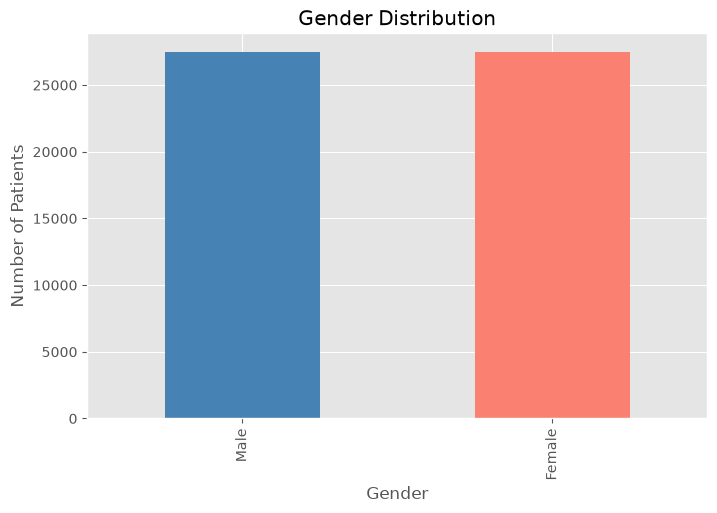

In [12]:
plt.figure(figsize=(8,5))

gender_count.plot(
    kind="bar",
    color=["steelblue","salmon"]
)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Patients")

plt.show()

## Business Insight

- Compare the number of male and female patients.
- If one gender dominates, hospitals can investigate whether this reflects disease prevalence or demographic factors.

In [13]:
gender_percent = (
    df["Gender"]
      .value_counts(normalize=True)
      *100
)

gender_percent.round(2)

Gender
Male      50.02
Female    49.98
Name: proportion, dtype: float64

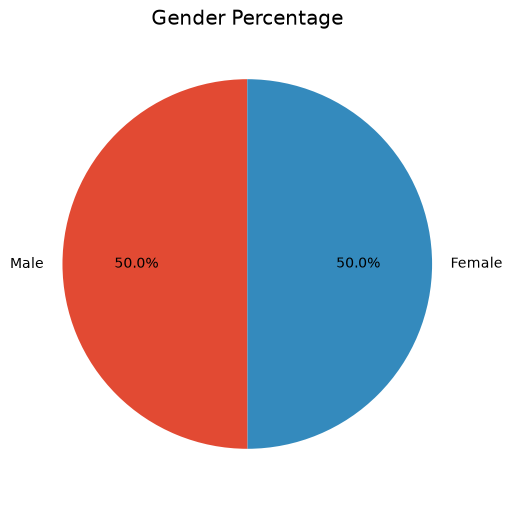

In [14]:
plt.figure(figsize=(6,6))

plt.pie(
    gender_count,
    labels=gender_count.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Gender Percentage")

plt.show()

# 2. Age Distribution

### Objective

Understand the age profile of patients.

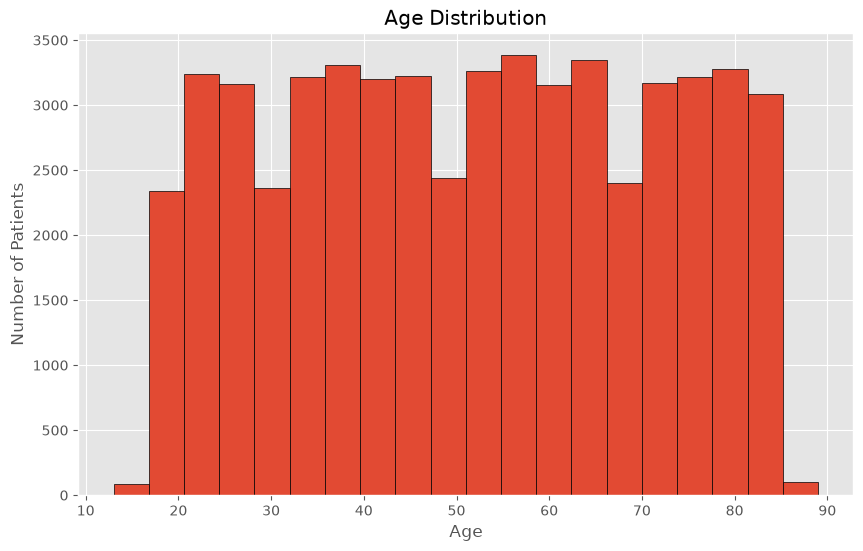

In [15]:
plt.figure(figsize=(10,6))

plt.hist(
    df["Age"],
    bins=20,
    edgecolor="black"
)

plt.title("Age Distribution")

plt.xlabel("Age")

plt.ylabel("Number of Patients")

plt.show()

In [16]:
print("Minimum Age :", df["Age"].min())

print("Maximum Age :", df["Age"].max())

print("Average Age :", round(df["Age"].mean(),2))

Minimum Age : 13
Maximum Age : 89
Average Age : 51.54


## Business Insight

- Identify which age groups use healthcare services most frequently.
- This helps hospitals plan specialized care for high-demand age groups.

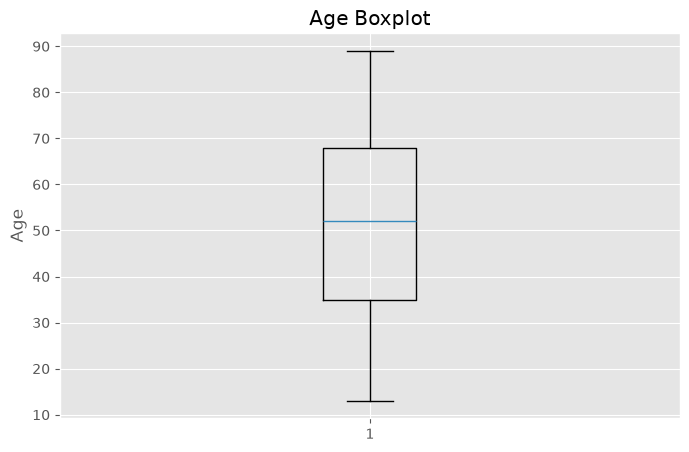

In [17]:
plt.figure(figsize=(8,5))

plt.boxplot(df["Age"])

plt.title("Age Boxplot")

plt.ylabel("Age")

plt.show()

In [18]:
blood = df["Blood Type"].value_counts()

blood

Blood Type
A-     6898
A+     6896
B+     6885
AB+    6882
AB-    6874
B-     6872
O+     6855
O-     6804
Name: count, dtype: int64

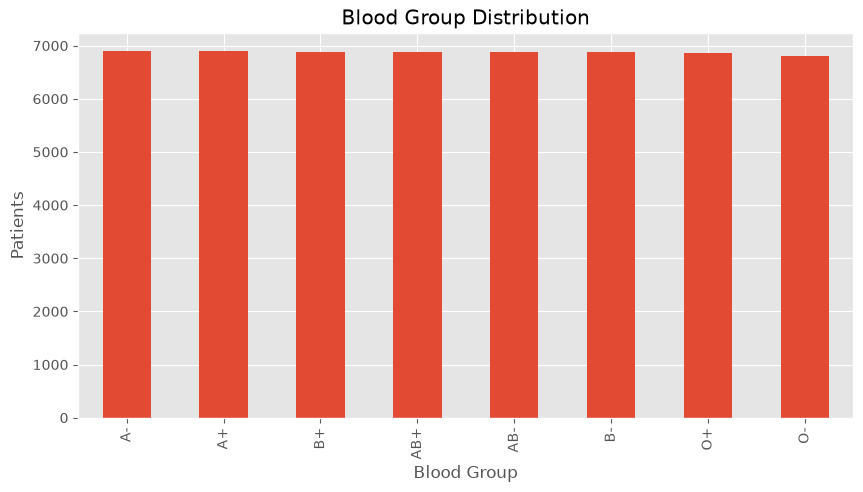

In [19]:
plt.figure(figsize=(10,5))

blood.plot(kind="bar")

plt.title("Blood Group Distribution")

plt.xlabel("Blood Group")

plt.ylabel("Patients")

plt.show()

## Business Insight

- Hospitals should maintain adequate blood inventory for the most common blood groups while ensuring rare blood groups remain available for emergencies.

In [20]:
condition = df["Medical Condition"].value_counts()

condition

Medical Condition
Arthritis       9218
Diabetes        9216
Hypertension    9151
Obesity         9146
Cancer          9140
Asthma          9095
Name: count, dtype: int64

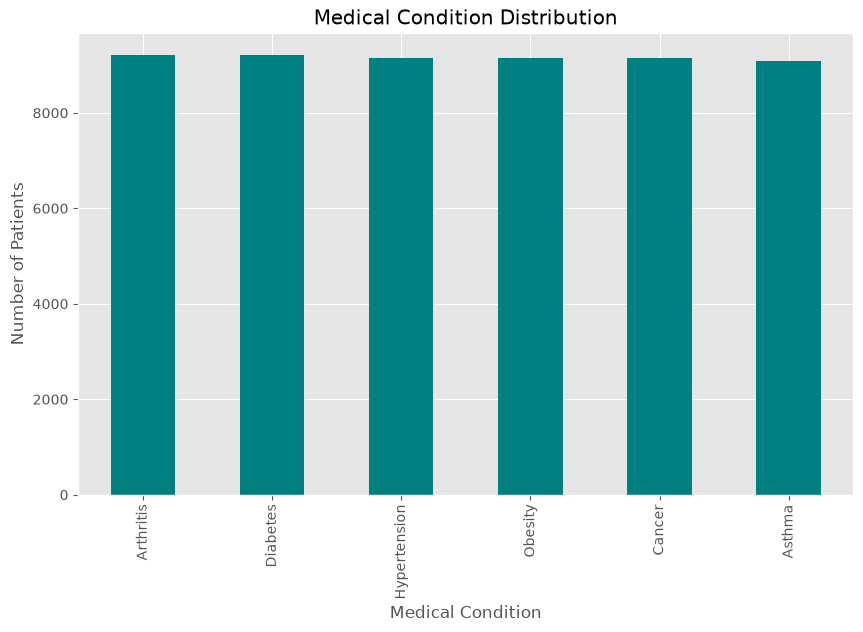

In [21]:
plt.figure(figsize=(10,6))

condition.plot(
    kind="bar",
    color="teal"
)

plt.title("Medical Condition Distribution")

plt.xlabel("Medical Condition")

plt.ylabel("Number of Patients")

plt.show()

## Business Insight

- The most common medical conditions may require additional hospital resources, specialized staff, and preventive healthcare initiatives.

In [22]:
condition

Medical Condition
Arthritis       9218
Diabetes        9216
Hypertension    9151
Obesity         9146
Cancer          9140
Asthma          9095
Name: count, dtype: int64

## Business Insight

- Arthritis has the highest number of patient admissions in the dataset.
- Asthma has the lowest number of admissions.
- The difference between conditions is relatively small, indicating that hospital resources should be distributed across all major disease categories instead of focusing on only one.

# 5. Billing Amount Analysis

### Business Question

How are treatment costs distributed across patients?

In [23]:
print("Minimum Billing Amount :", round(df["Billing Amount"].min(), 2))

print("Maximum Billing Amount :", round(df["Billing Amount"].max(), 2))

print("Average Billing Amount :", round(df["Billing Amount"].mean(), 2))

print("Median Billing Amount :", round(df["Billing Amount"].median(), 2))

Minimum Billing Amount : -2008.49
Maximum Billing Amount : 52764.28
Average Billing Amount : 25544.31
Median Billing Amount : 25542.75


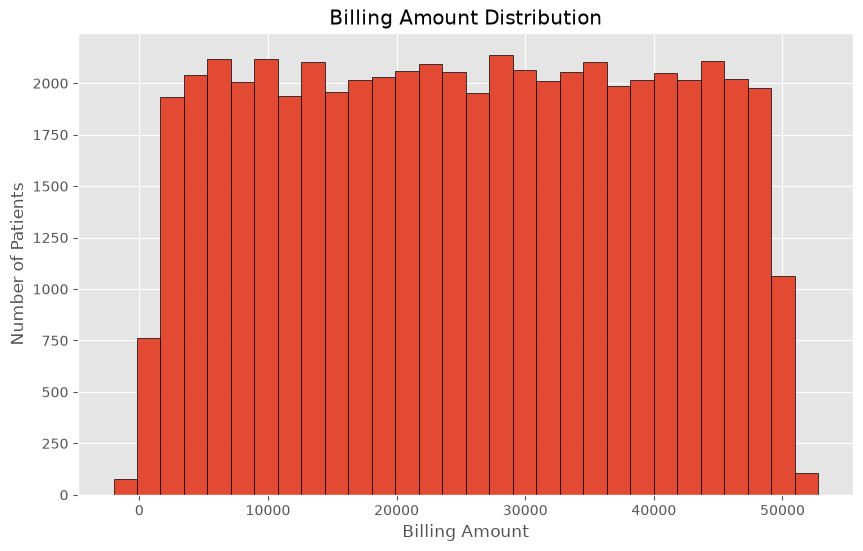

In [24]:
plt.figure(figsize=(10,6))

plt.hist(
    df["Billing Amount"],
    bins=30,
    edgecolor="black"
)

plt.title("Billing Amount Distribution")

plt.xlabel("Billing Amount")

plt.ylabel("Number of Patients")

plt.show()

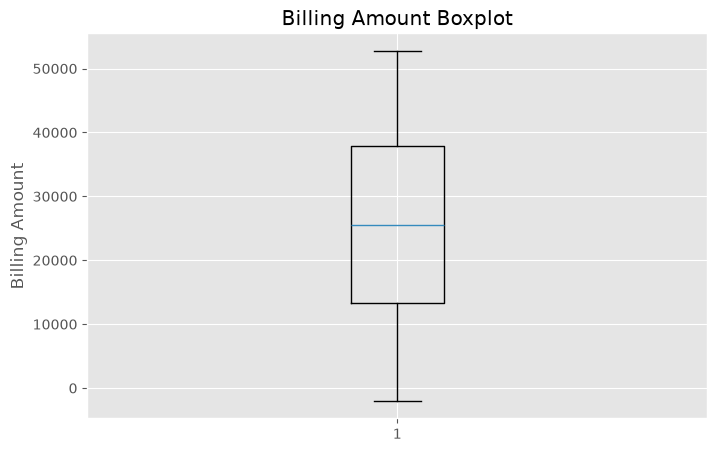

In [25]:
plt.figure(figsize=(8,5))

plt.boxplot(df["Billing Amount"])

plt.title("Billing Amount Boxplot")

plt.ylabel("Billing Amount")

plt.show()

## Business Insight

- Billing amounts vary significantly across patients.
- The distribution helps identify high-cost treatments and potential outliers.
- Understanding billing patterns can support budgeting, pricing reviews, and cost management.

# 6. Average Billing by Medical Condition

### Business Question

Which medical conditions generate the highest average billing amount?

In [26]:
billing_condition = (
    df.groupby("Medical Condition")["Billing Amount"]
      .mean()
      .sort_values(ascending=False)
)

billing_condition

Medical Condition
Obesity         25804.361902
Diabetes        25660.478635
Asthma          25633.461696
Arthritis       25511.783246
Hypertension    25503.058720
Cancer          25152.322947
Name: Billing Amount, dtype: float64

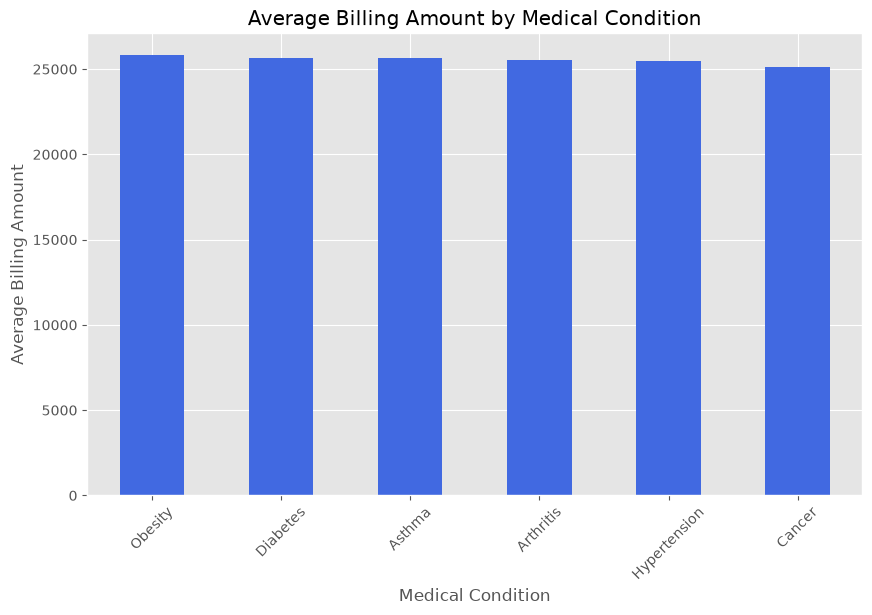

In [27]:
plt.figure(figsize=(10,6))

billing_condition.plot(
    kind="bar",
    color="royalblue"
)

plt.title("Average Billing Amount by Medical Condition")

plt.xlabel("Medical Condition")

plt.ylabel("Average Billing Amount")

plt.xticks(rotation=45)

plt.show()

# 7. Billing Analysis by Admission Type

### Business Question

Which admission type results in the highest average billing amount?

In [28]:
billing_admission = (
    df.groupby("Admission Type")["Billing Amount"]
      .mean()
      .sort_values(ascending=False)
)

billing_admission

Admission Type
Elective     25612.139673
Urgent       25514.532045
Emergency    25505.332240
Name: Billing Amount, dtype: float64

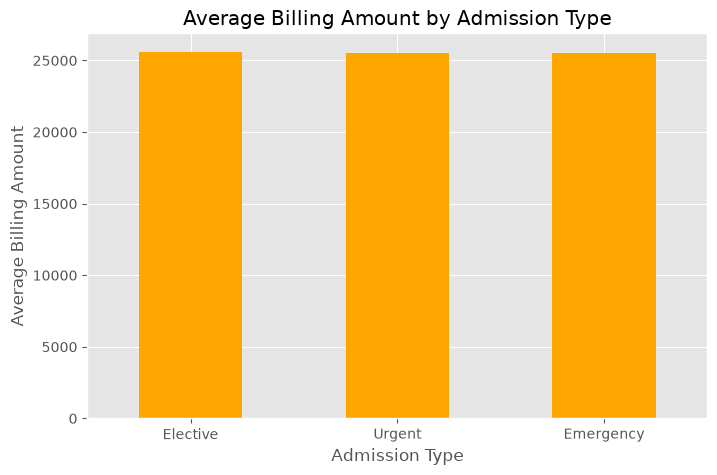

In [29]:
plt.figure(figsize=(8,5))

billing_admission.plot(
    kind="bar",
    color="orange"
)

plt.title("Average Billing Amount by Admission Type")

plt.xlabel("Admission Type")

plt.ylabel("Average Billing Amount")

plt.xticks(rotation=0)

plt.show()

## Business Insight

- Analyze whether Emergency, Urgent, or Elective admissions are associated with higher treatment costs.
- This information helps hospitals forecast expenses and allocate resources effectively.

In [30]:
top_hospitals = (
    df["Hospital"]
      .value_counts()
      .head(10)
)

top_hospitals

Hospital
LLC Smith      44
Ltd Smith      39
Johnson PLC    37
Smith Ltd      37
Smith PLC      36
Smith Group    36
Johnson Inc    34
Smith Inc      33
Smith LLC      32
Group Smith    32
Name: count, dtype: int64

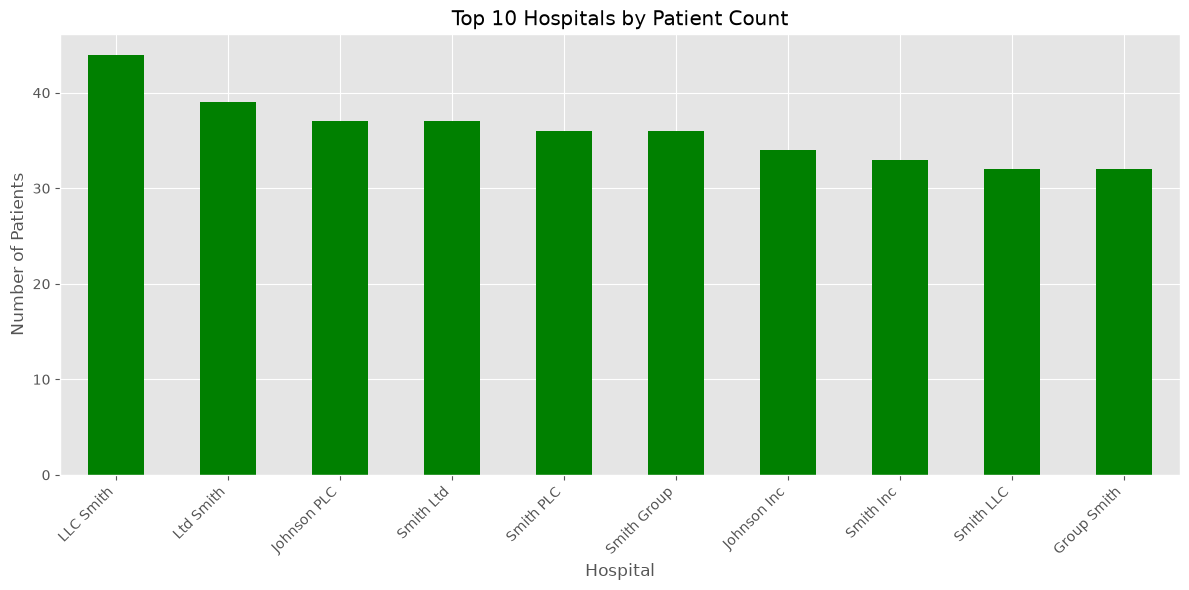

In [31]:
plt.figure(figsize=(12,6))

top_hospitals.plot(
    kind="bar",
    color="green"
)

plt.title("Top 10 Hospitals by Patient Count")

plt.xlabel("Hospital")

plt.ylabel("Number of Patients")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.show()

## Business Insight

- The hospitals with the highest patient volume may require more staff, beds, and operational resources.
- Comparing patient volume helps identify high-demand healthcare facilities.

# 9. Doctor Performance Analysis

### Business Question

Which doctors treated the highest number of patients?

In [32]:
top_doctors = (
    df["Doctor"]
      .value_counts()
      .head(10)
)

top_doctors

Doctor
Michael Smith       27
John Smith          22
Robert Smith        21
James Smith         20
Michael Johnson     20
Robert Johnson      19
David Smith         19
Michael Williams    18
Matthew Smith       17
John Johnson        17
Name: count, dtype: int64

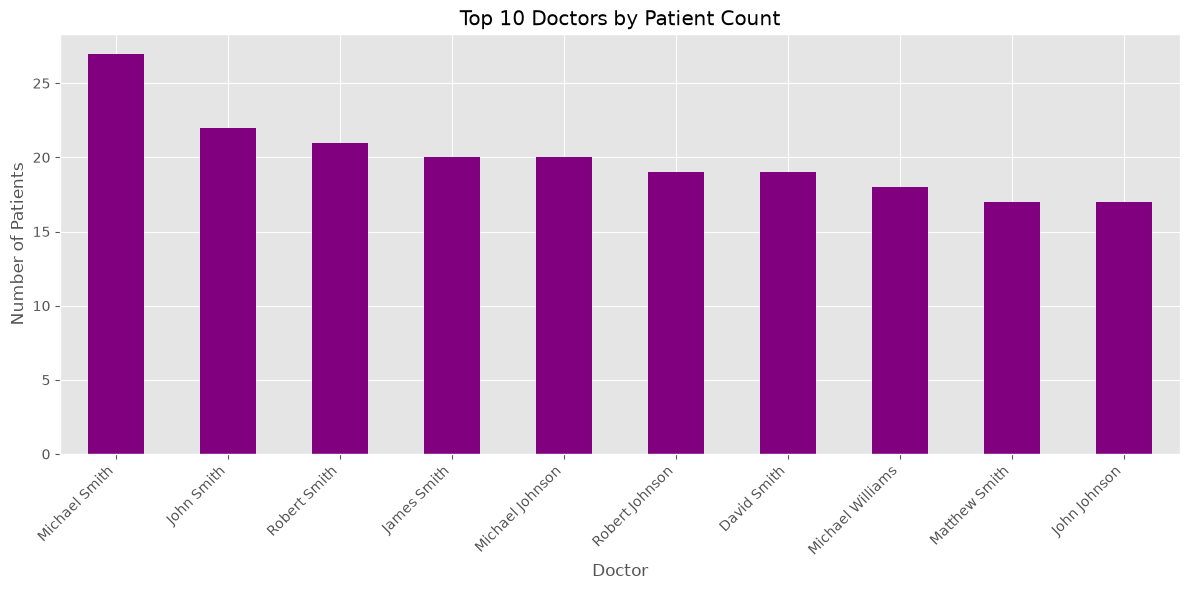

In [33]:
plt.figure(figsize=(12,6))

top_doctors.plot(
    kind="bar",
    color="purple"
)

plt.title("Top 10 Doctors by Patient Count")

plt.xlabel("Doctor")

plt.ylabel("Number of Patients")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.show()

## Business Insight

- Doctors handling a large number of patients may indicate high demand for their specialty.
- Hospitals can use this information to optimize staffing and appointment scheduling.

# 10. Insurance Provider Analysis

### Business Question

Which insurance providers cover the highest number of patients?

In [34]:
insurance = df["Insurance Provider"].value_counts()

insurance

Insurance Provider
Cigna               11139
Medicare            11039
UnitedHealthcare    11014
Blue Cross          10952
Aetna               10822
Name: count, dtype: int64

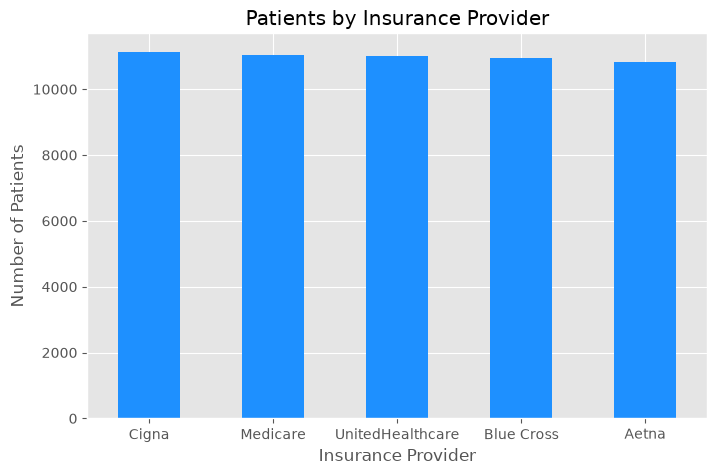

In [35]:
plt.figure(figsize=(8,5))

insurance.plot(
    kind="bar",
    color="dodgerblue"
)

plt.title("Patients by Insurance Provider")
plt.xlabel("Insurance Provider")
plt.ylabel("Number of Patients")

plt.xticks(rotation=0)

plt.show()

## Business Insight

- Compare the number of patients covered by each insurance provider.
- Providers with higher patient counts may be strategic partners for hospitals.

# 11. Medication Analysis

### Business Question

Which medications are prescribed most frequently?

In [36]:
medication = df["Medication"].value_counts()

medication

Medication
Lipitor        11038
Ibuprofen      11023
Aspirin        10984
Paracetamol    10965
Penicillin     10956
Name: count, dtype: int64

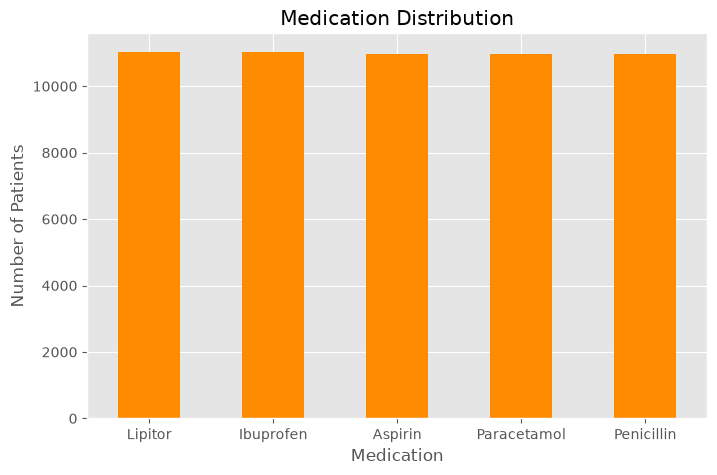

In [37]:
plt.figure(figsize=(8,5))

medication.plot(
    kind="bar",
    color="darkorange"
)

plt.title("Medication Distribution")
plt.xlabel("Medication")
plt.ylabel("Number of Patients")

plt.xticks(rotation=0)

plt.show()

# 12. Test Result Analysis

### Business Question

What are the most common patient test outcomes?

In [38]:
test_results = df["Test Results"].value_counts()

test_results

Test Results
Abnormal        18437
Normal          18331
Inconclusive    18198
Name: count, dtype: int64

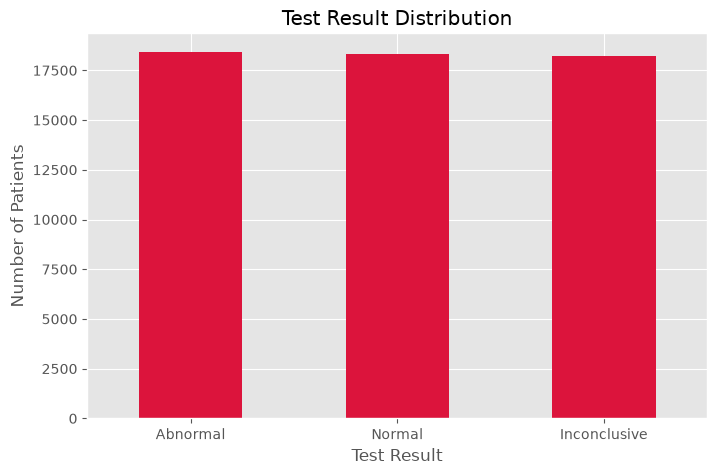

In [39]:
plt.figure(figsize=(8,5))

test_results.plot(
    kind="bar",
    color="crimson"
)

plt.title("Test Result Distribution")
plt.xlabel("Test Result")
plt.ylabel("Number of Patients")

plt.xticks(rotation=0)

plt.show()

## Business Insight

- Understanding test result patterns helps evaluate patient outcomes.
- A high proportion of abnormal results may indicate a need for additional diagnostic or preventive care.

# 13. Monthly Admission Trend

### Business Question

How do patient admissions change over time?

In [40]:
df["Admission Month"] = df["Date of Admission"].dt.to_period("M")

monthly = df.groupby("Admission Month").size()

monthly

Admission Month
2019-05    677
2019-06    899
2019-07    951
2019-08    985
2019-09    924
          ... 
2024-01    903
2024-02    869
2024-03    902
2024-04    941
2024-05    212
Freq: M, Length: 61, dtype: int64

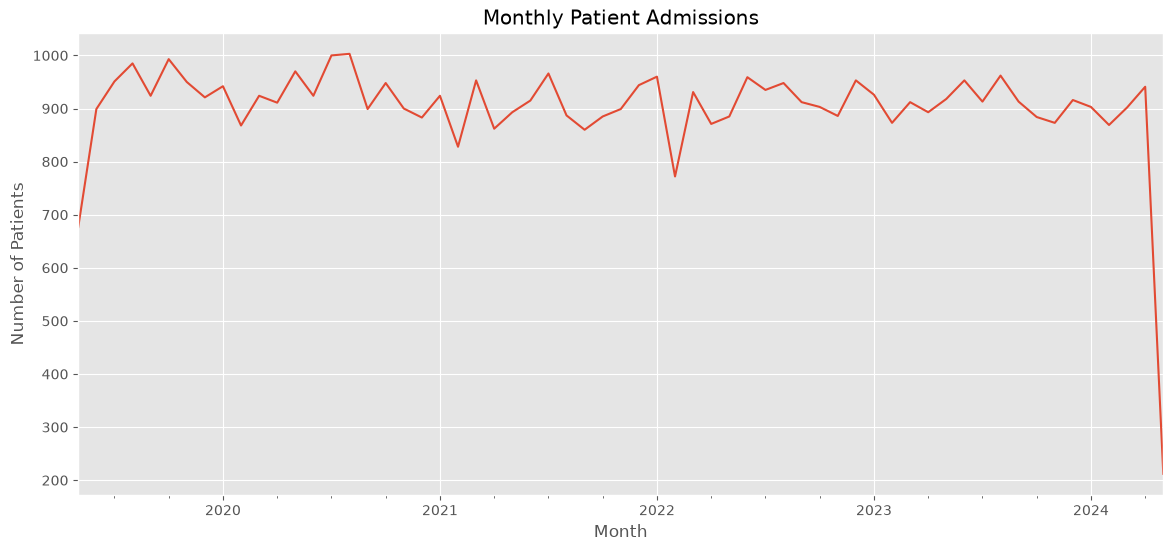

In [41]:
plt.figure(figsize=(14,6))

monthly.plot()

plt.title("Monthly Patient Admissions")
plt.xlabel("Month")
plt.ylabel("Number of Patients")

plt.grid(True)

plt.show()

## Business Insight

- Monthly admission trends help hospitals forecast patient demand.
- Peak periods may require additional staffing and resource planning.

# 14. Correlation Analysis

### Business Question

Is there any relationship between numerical variables?

In [42]:
numerical = df.select_dtypes(include=["int64", "float64"])

corr = numerical.corr()

corr

,Age,Billing Amount,Room Number
Age,1.000000,-0.003427,-0.000352
Billing Amount,-0.003427,1.000000,-0.003930
Room Number,-0.000352,-0.003930,1.000000


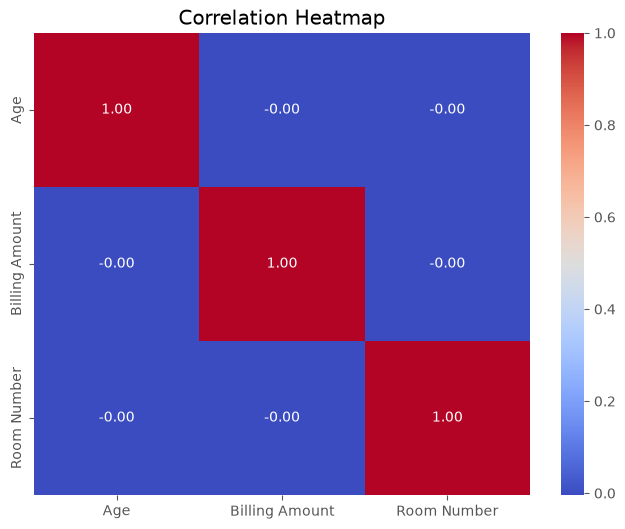

In [43]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

## Business Insight

- Correlation analysis helps identify relationships between numerical variables.
- Strong positive or negative correlations can guide further investigation and predictive modeling.

In [44]:
plt.savefig("../Images/EDA_Charts/chart_name.png")

<Figure size 640x480 with 0 Axes>